In [1]:
# Cкачаем датасет с Kaggle в Notebook:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset")

Skipping, found downloaded files in ".\default-of-credit-card-clients-dataset" (use force=True to force download)


In [2]:
import os
os.listdir()

['+.docx',
 '.ipynb_checkpoints',
 'default-of-credit-card-clients-dataset',
 'kaggle.json',
 'models',
 'model_v1.pkl',
 'Сессионное задание. Итоговый проект. Внедрение моделей ML.ipynb']

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# загрузка данных

In [4]:
df = pd.read_csv('default-of-credit-card-clients-dataset/UCI_Credit_Card.csv')
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


Описание: датасет содержит информацию о клиентах кредитной карты на Тайване с таргетом default.payment.next.month (дефолт в следующем месяце). Включает демографические данные, историю платежей, суммы счетов.

In [5]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

# исследовательский анализ данных (EDA)

In [6]:
# Удаляим ID, он не нужен модели
df = df.drop(columns=["ID"])
df.shape

(30000, 24)

In [7]:
# Информация о df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

In [8]:
# контрольный на проверку пропусков
df.isnull().sum().sum()

np.int64(0)

In [9]:
# Статистика df
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [10]:
# Корреляция всех признаков
corr = df.corr(numeric_only=True)                               # матрица корреляций для всех числовых признаков

corr["default.payment.next.month"].sort_values(ascending=False) # корреляция каждого признака с target с сортировкой по убыванию

default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default.payment.next.month, dtype: float64

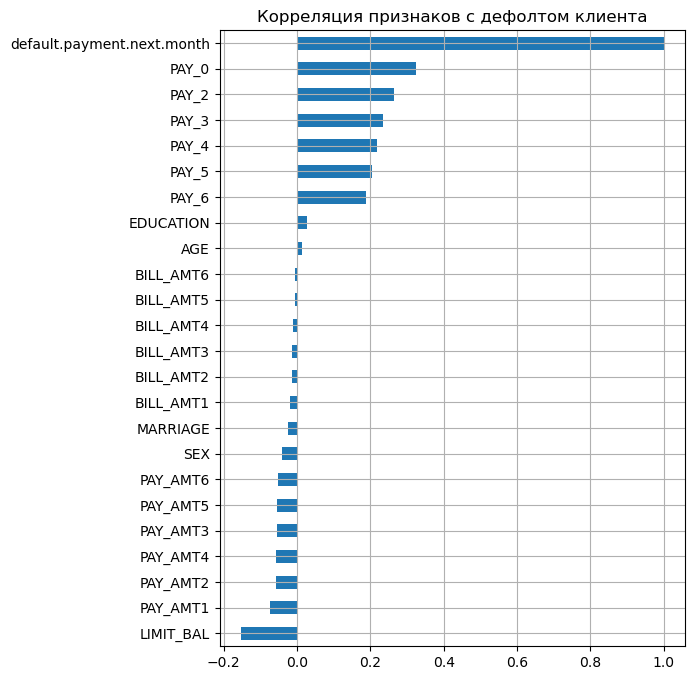

In [11]:
corr["default.payment.next.month"].sort_values().plot(kind="barh", figsize=(6, 8))
plt.title("Корреляция признаков с дефолтом клиента")
plt.grid()

- Главный драйвер дефолта — история просрочек., т.е. если клиент уже задерживал платежи, шанс дефолта резко выше.  
- Второй важный признак: LIMIT_BAL → чем выше кредитный лимит, тем ниже риск дефолта.  
- Остальные признаки влияют слабее.

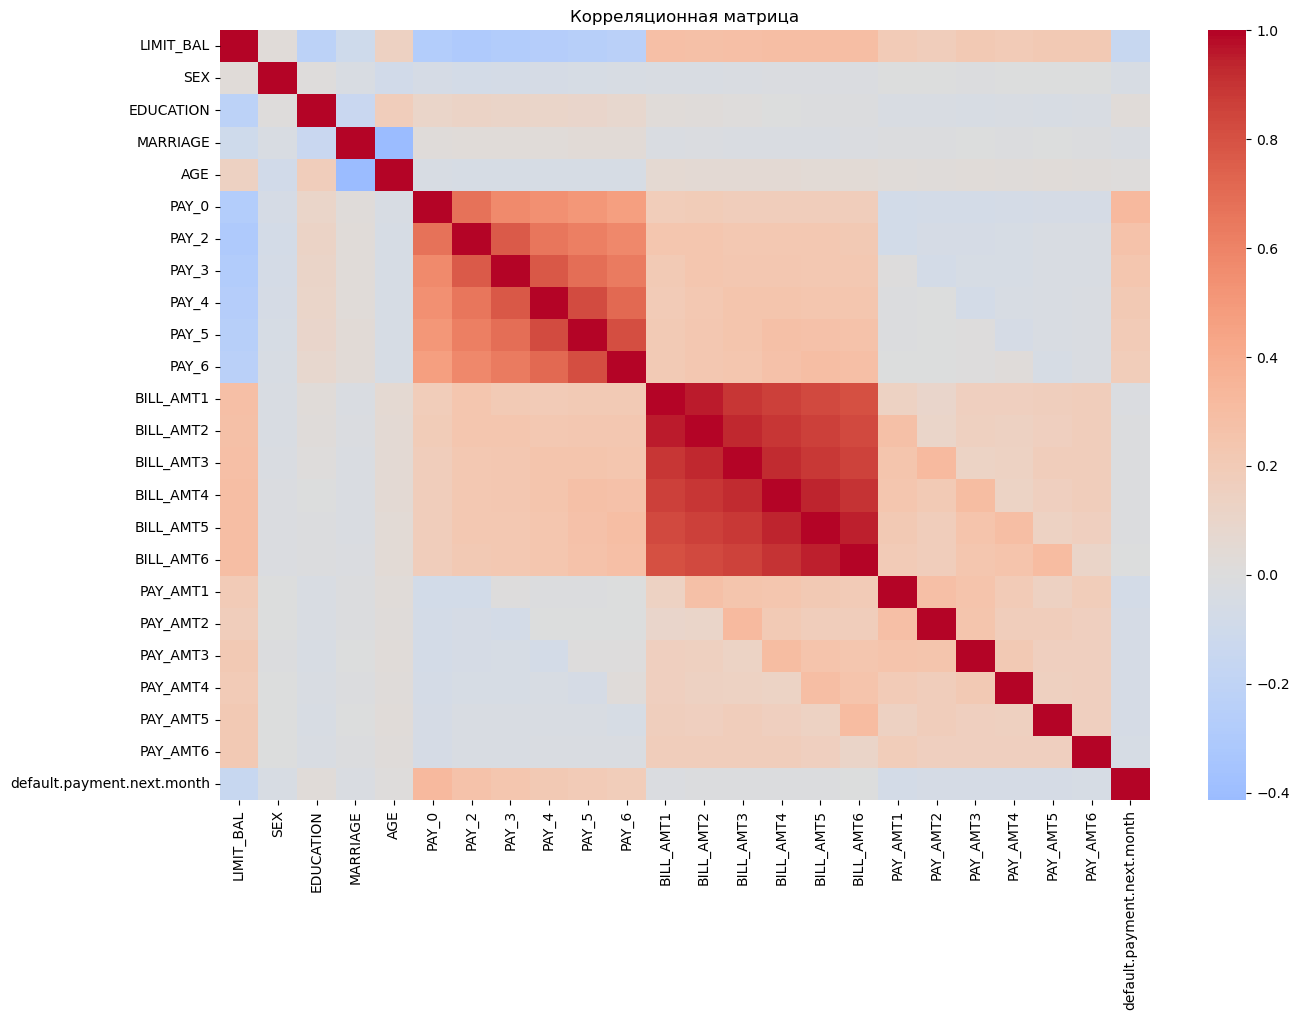

In [12]:
# Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Корреляционная матрица")
plt.show()

**Блок просрочек:** PAY_0 ... PAY_6 (красный квадрат):  
- признаки сильно коррелируют между собой.
- клиент, который задерживал платежи в одном месяце, часто задерживал и в других.

**Блок счетов:** BILL_AMT1..6 (красный квадрат):
- Если у клиента высокий долг сейчас, он часто высокий и в прошлых месяцах (что логично).

**Блок платежей:** PAY_AMT1..6:
- Есть умеренная корреляция.
- Если клиент платит много в одном месяце — часто платит и в других.

LIMIT_BAL связан с BILL_AMT и PAY_AMT: Большой лимит → больше траты → больше платежи.  
Target связан сильнее всего с PAY_*.

# создание/улучшение признаков (Feature Engineering)

In [13]:
# Средняя просрочка
df["avg_delay"] = df[["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].mean(axis=1)

# Максимальная просрочка
df["max_delay"] = df[["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].max(axis=1)

# Средний долг
df["avg_bill"] = df[[
    "BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6"
]].mean(axis=1)

# Средний платёж
df["avg_pay"] = df[[
    "PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"
]].mean(axis=1)

# Коэффициент использования лимита
df["utilization"] = df["avg_bill"] / (df["LIMIT_BAL"] + 1)

In [14]:
df.shape

(30000, 29)

# создание несколько моделей с последующим сравнением между собой (Modeling) + проверка качества модели (Evaluation)

для сравнения 3 модели:
- LogisticRegression
- RandomForestClassifier
- GradientBoostingClassifier

In [15]:
# Train/Test split
X = df.drop(columns=["default.payment.next.month"])
y = df["default.payment.next.month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
# Модели
models = {
    "LogisticRegression": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "RandomForest": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "GradientBoosting": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ])
}

In [17]:
# ROC-AUC + Leaderboard
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, proba)
    
    results.append({
        "Model": name,
        "ROC_AUC": round(auc, 4)
    })

leaderboard = pd.DataFrame(results).sort_values(
    by="ROC_AUC",
    ascending=False
)

leaderboard

,Model,ROC_AUC
2,GradientBoosting,0.7817
1,RandomForest,0.7774
0,LogisticRegression,0.7241


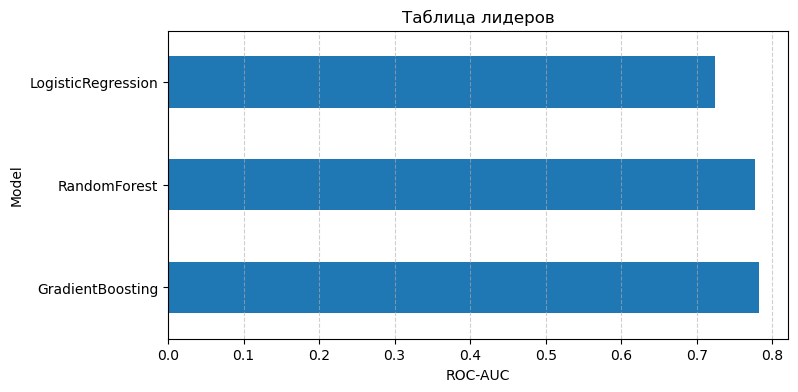

In [18]:
# график
leaderboard.plot(
    kind="barh",
    x="Model",
    y="ROC_AUC",
    legend=False,
    figsize=(8,4)
)

plt.title("Таблица лидеров")
plt.xlabel("ROC-AUC")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.show()

**Итог**
| Модель                | ROC-AUC    |
| --------------------- | ---------- |
| 🥇 GradientBoosting   | **0.7817** |
| 🥈 RandomForest       | 0.7774     |
| 🥉 LogisticRegression | 0.7241     |

GradientBoostingClassifier - лучше всех улавливает закономерности дефолта.

В рамках сравнения трёх алгоритмов классификации наилучшее качество по метрике ROC-AUC показала модель Gradient Boosting (0.7817), поэтому именно она была выбрана для дальнейшего внедрения в веб-сервис прогнозирования дефолта.

In [19]:
# Сохраним обученную модель + список признаков с использованием joblib и пойдем дальше к deployment
import joblib

# обучает лучшую модель на всех данных
best_model = models["GradientBoosting"]
best_model.fit(X, y)

# сохраняет модель
joblib.dump(best_model, "models/model_v1.pkl")
# сохраняет порядок и названия признаков
joblib.dump(list(X.columns), "models/features_v1.pkl")

print("Модель сохранена:", "models/model_v1.pkl")
print("Признаки сохранены:", "models/features_v1.pkl")

Модель сохранена: models/model_v1.pkl
Признаки сохранены: models/features_v1.pkl
